In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Math': [85, 90, np.nan, 40, 500, 78, 89, 95],
    'Science': [88, 92, 85, np.nan, 91, 76, 84, 200],
    'English': [75, 80, 79, 82, 81, np.nan, 77, 78]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)


Original Dataset:
  Name   Math  Science  English
0    A   85.0     88.0     75.0
1    B   90.0     92.0     80.0
2    C    NaN     85.0     79.0
3    D   40.0      NaN     82.0
4    E  500.0     91.0     81.0
5    F   78.0     76.0      NaN
6    G   89.0     84.0     77.0
7    H   95.0    200.0     78.0


<Axes: >

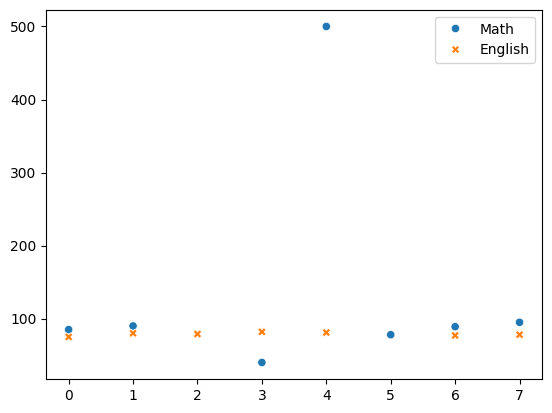

In [25]:
sns.scatterplot(data=df[['Math','English']])

<Axes: >

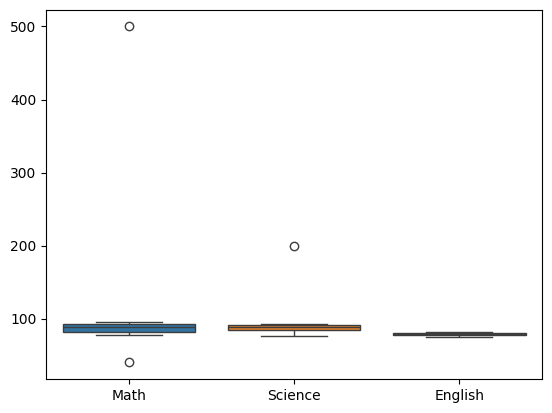

In [18]:
sns.boxplot(data=df[['Math','Science','English']])

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     8 non-null      object 
 1   Math     7 non-null      float64
 2   Science  7 non-null      float64
 3   English  7 non-null      float64
dtypes: float64(3), object(1)
memory usage: 388.0+ bytes


In [41]:
print(df.dtypes)

Name        object
Math       float64
Science    float64
English    float64
dtype: object


In [42]:
df.describe()

,Math,Science,English
count,7.000000,7.000000,7.000000
mean,139.571429,102.285714,78.857143
std,159.996726,43.415490,2.410295
min,40.000000,76.000000,75.000000
25%,81.500000,84.500000,77.500000
50%,89.000000,88.000000,79.000000
75%,92.500000,91.500000,80.500000
max,500.000000,200.000000,82.000000


In [48]:
df.isnull().sum()

Name       0
Math       1
Science    1
English    1
dtype: int64

In [70]:
df['Math']=df['Math'].fillna(df['Math'].mean())
df['Science']=df['Science'].fillna(df['Science'].mean())
df['English']=df['English'].fillna(df['English'].mean())
print("\nDataset After Handling Missing Values:")
df



Dataset After Handling Missing Values:


,Name,Math,Science,English
0,A,85.000000,88.000000,75.000000
1,B,90.000000,92.000000,80.000000
2,C,139.571429,85.000000,79.000000
3,D,40.000000,102.285714,82.000000
4,E,500.000000,91.000000,81.000000
5,F,78.000000,76.000000,78.857143
6,G,89.000000,84.000000,77.000000
7,H,95.000000,200.000000,78.000000


In [71]:
Q1 = df['Math'].quantile(0.25)
Q3 = df['Math'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nLower Limit:", lower_limit)
print("Upper Limit:", upper_limit)



Lower Limit: 48.91071428571429
Upper Limit: 140.48214285714283


In [51]:
# Detect outliers

outliers = df[(df['Math'] < lower_limit) |
              (df['Math'] > upper_limit)]

print("\nOutliers in Math:")
print(outliers)


Outliers in Math:
  Name   Math     Science  English
3    D   40.0  102.285714     82.0
4    E  500.0   91.000000     81.0


In [72]:
meadin=df['Math'].median()
# syntax np.where(condition , if_true,if_false)
df['Math']=np.where(((df['Math']<=lower_limit) | (df['Math']>=upper_limit)),meadin,df['Math']) 

In [73]:
df

,Name,Math,Science,English
0,A,85.000000,88.000000,75.000000
1,B,90.000000,92.000000,80.000000
2,C,139.571429,85.000000,79.000000
3,D,89.500000,102.285714,82.000000
4,E,89.500000,91.000000,81.000000
5,F,78.000000,76.000000,78.857143
6,G,89.000000,84.000000,77.000000
7,H,95.000000,200.000000,78.000000


In [74]:
# if u want to remove the outliers
# df = df[(df["Math"] >= lower) & (df["Math"] <= upper)]
# print(df)

In [76]:
df["Math_Normalized"] = (df["Math"] - df["Math"].min())/(df["Math"].max() - df["Math"].min())
print(df[["Math", "Math_Normalized"]])

         Math  Math_Normalized
0   85.000000         0.113689
1   90.000000         0.194896
2  139.571429         1.000000
3   89.500000         0.186775
4   89.500000         0.186775
5   78.000000         0.000000
6   89.000000         0.178654
7   95.000000         0.276102


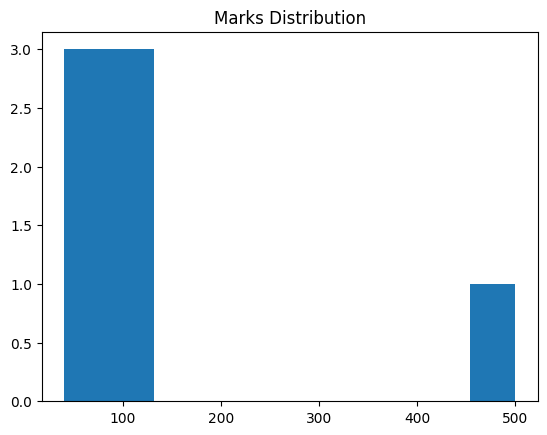

In [28]:
plt.hist(df['Math'])

plt.title("Marks Distribution")

plt.show()